# Study 775 — Halloween-Candy 🎃

*For the curious.* Everyone *knows* Halloween is Hershey's Super Bowl — the biggest candy weekend of the year — so surely you buy `HSY` into Oct 31 and ride the trick-or-treat haul. We put 32 Halloweens (1994→2025) on the stand and asked the tape two plain questions: **does HSY rally into Halloween?** and **does it fade after?** The answer is a double bust — with an unexpected direction.

## The claim, and why it's a clean test

Halloween is a **fixed public holiday — always October 31** — so *buy K sessions before, sell on the day* is calendar-known decades ahead and zero-look-ahead. We measure HSY's **abnormal** return (HSY − SPY, total-return) so we're not just measuring a slow staple drifting with the market.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from halloween_candy import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching HSY + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Halloweens resolved")


panel loaded; 32 of 32 Halloweens resolved


## The Halloween calendar we test (one event per year, Oct 31)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'halloween_date']).head(8)

,year,halloween_date
0,1994,1994-10-31
1,1995,1995-10-31
2,1996,1996-10-31
3,1997,1997-10-31
4,1998,1998-10-31
5,1999,1999-10-31
6,2000,2000-10-31
7,2001,2001-10-31


## The picture: mean cumulative abnormal return around Halloween

Offset 0 is Halloween. Left of zero is the *run-up* (the supposed rally in); right of zero is the *fade* window.

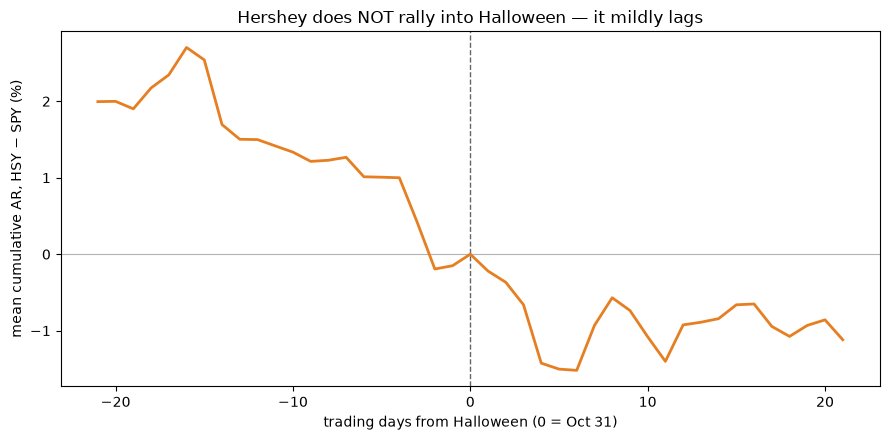

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#e67e22', lw=2)
ax.set_xlabel('trading days from Halloween (0 = Oct 31)')
ax.set_ylabel('mean cumulative AR, HSY − SPY (%)')
ax.set_title('Hershey does NOT rally into Halloween — it mildly lags')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | -1.19% | -1.34 | 14/32 |
| 1-month run-up | **-2.01%** | **-1.76** | 12/32 |
| 2-week fade | -1.08% | -1.32 | 9/32 |
| 1-month fade | -1.12% | -0.92 | 10/32 |

The bullish folklore is **absent, if anything inverted**: in the month *into* Halloween HSY has under-performed SPY by 2.01% on average (*t* = -1.76) — the opposite of a rally in. And the 'sell the season' fade? Also mildly negative, and not significant either. Every window points down, none of them clears the significance bar (|*t*| < 2).

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n=32  mean=-1.192%  t=-1.339  hit 14/32
1mo run-up   n=32  mean=-2.012%  t=-1.759  hit 12/32
2wk fade     n=32  mean=-1.080%  t=-1.319  hit 9/32
1mo fade     n=32  mean=-1.119%  t=-0.919  hit 10/32


## So what?

The famous *buy Hershey for the Halloween candy season* trade is folklore: the stock doesn't rally in (it mildly lags the market) and it doesn't pop after either. Nothing crosses the significance bar. The best cut — the 1-month pre-Halloween softness — is a sub-threshold, *opposite-direction* whiff. Verdict: **No signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control that shows the detector *would* have caught a real seasonal had one existed.